# FLAGGING VENDOR INVOICES FOR MANUAL REVIEW

*OBJECTIVE* :- predict whether a vendor invoice should be flagged for manual reviews basedon on abnormal cost, very very high cost ,freight or delivery paterns ,inorder to reduce the financial risk
and improve the human resources and finance , etc........ 

In [1]:
import pandas as pd
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# Correct full path
conn = sqlite3.connect(r'C:\Users\Ansh Mishra\Desktop\PythoncourseML\datasets\inventory.db')

# Check tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('purchases',), ('purchase_prices',), ('vendor_invoice',), ('begin_inventory',), ('end_inventory',)]


In [3]:
tables = ['purchases', 'purchase_prices', 'vendor_invoice', 'begin_inventory', 'end_inventory']

for table in tables:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    df.to_csv(f'{table}.csv', index=False)
    print(f'{table}.csv saved!')

conn.close()

purchases.csv saved!
purchase_prices.csv saved!
vendor_invoice.csv saved!
begin_inventory.csv saved!
end_inventory.csv saved!


In [4]:

purchases_df = pd.read_csv('purchases.csv')
#calculating the  delay column first
purchases_df['receiving_delay'] = (
    pd.to_datetime(purchases_df['ReceivingDate']) - 
    pd.to_datetime(purchases_df['PODate'])
).dt.days

# after that... doing groupby 
purchase_avg_df = purchases_df.groupby('PONumber').agg(
    total_brands        = ('Brand', 'nunique'),
    total_item_quantity = ('Quantity', 'sum'),
    total_item_dollars  = ('Dollars', 'sum'),
    avg_receiving_delay = ('receiving_delay', 'mean')
).reset_index()

purchase_avg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [8]:

vendor_invoice_df = pd.read_csv('vendor_invoice.csv')
vendor_invoice_df['days_po_to_invoice'] = (
    pd.to_datetime(vendor_invoice_df['InvoiceDate']) -
    pd.to_datetime(vendor_invoice_df['PODate'])
).dt.days

vendor_invoice_df['days_to_pay'] = (
    pd.to_datetime(vendor_invoice_df['PayDate']) -
    pd.to_datetime(vendor_invoice_df['InvoiceDate'])
).dt.days

# select needed columns
vi_df = vendor_invoice_df[[
    'PONumber',
    'Quantity',
    'Dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay'
]].rename(columns={
    'Quantity' : 'invoice_quantity',
    'Dollars'  : 'invoice_dollars'
})

In [12]:
# SQL LEFT JOIN → pandas merge with how='left'
final_df = vi_df.merge(
    purchase_avg_df,
    on='PONumber',      # join on PONumber
    how='left'          # LEFT JOIN
)

final_df.head()
#print(final_df.shape)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14,43,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16,45,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16,38,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23,24,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14,36,29,1935,15527.25,8.752809


In [13]:
final_df.isnull()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5538,False,False,False,False,False,False,False,False,False,False
5539,False,False,False,False,False,False,False,False,False,False
5540,False,False,False,False,False,False,False,False,False,False
5541,False,False,False,False,False,False,False,False,False,False


In [15]:
final_df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice       int64
days_to_pay              int64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [18]:
def create_invoice_risk_label(row):
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


final_df["flag_invoice"] = final_df.apply(create_invoice_risk_label, axis=1)
final_df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

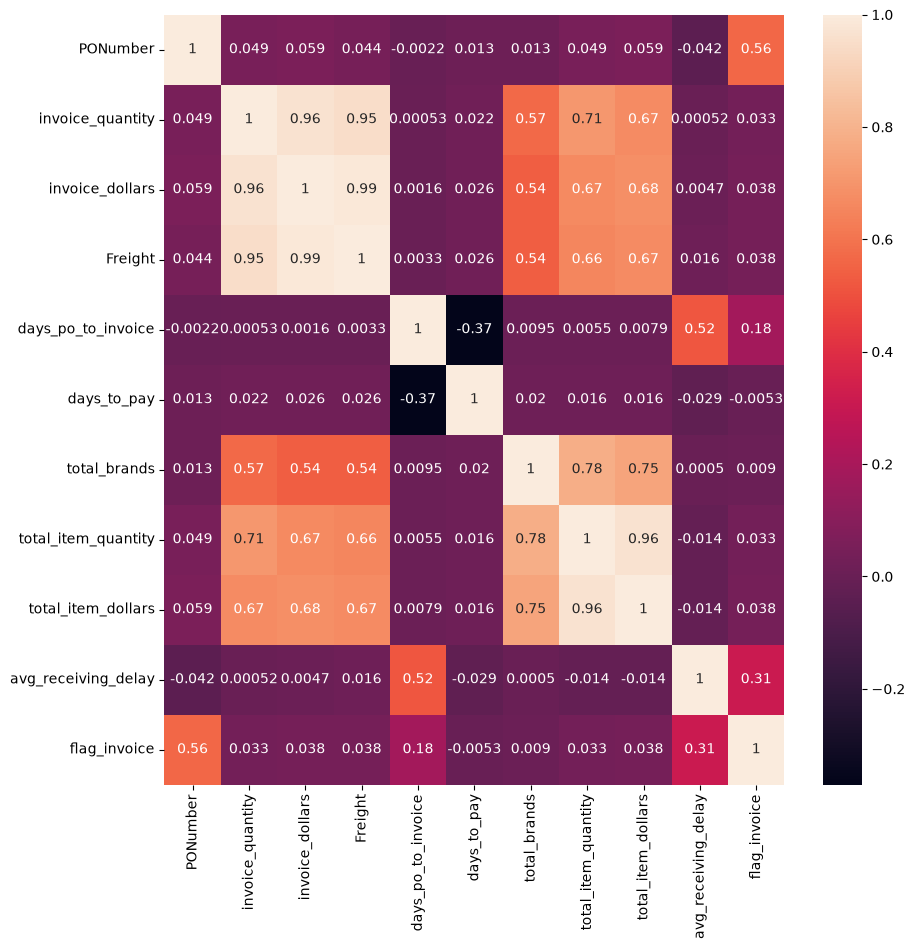

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(final_df.corr() , annot=True)
plt.show()


In [26]:
flagged = final_df[final_df['flag_invoice'] == 1]
normal = final_df[final_df['flag_invoice'] == 0]

In [27]:

significant_features = []
non_significant_features = []
results = []

metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [28]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [29]:
significant_features 

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [ ]:
non_significant_features 
#we dont need them as their p value(that value is random) is high thats why  we can also drop them

['days_to_pay', 'total_brands']

In [31]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [44]:
from sklearn.model_selection import train_test_split
X = final_df[['invoice_quantity',
              'invoice_dollars',
              'Freight',
              'days_po_to_invoice',
              'total_item_quantity',
              'total_item_dollars']]

Y = final_df['flag_invoice']
#TEST TRAIN SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducibility
)

In [ ]:
X.describe().round()


(5543, 5)

In [46]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

# fit on TRAIN only -->learns mean and std from train
# transform train --> applies scaling to train
X_train_scaled = scaler.fit_transform(X_train)

# only transform test --> uses SAME mean/std from train
# never fit on test! --> prevents data leakage 
X_test_scaled = scaler.transform(X_test)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, Y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, Y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model, X_test, Y_test, model_name):
    preds = model.predict(X_test)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy  : {accuracy_score(Y_test, preds)*100:.2f}%")
    print(f"Precision : {precision_score(Y_test, preds)*100:.2f}%")
    print(f"Recall    : {recall_score(Y_test, preds)*100:.2f}%")
    print(f"F1 Score  : {f1_score(Y_test, preds)*100:.2f}%")
    print(f"Confusion Matrix:\n{confusion_matrix(Y_test, preds)}")

In [65]:
evaluate_model(model1, X_test_scaled, Y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, Y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, Y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy  : 66.01%
Precision : 59.46%
Recall    : 5.73%
F1 Score  : 10.45%
Confusion Matrix:
[[710  15]
 [362  22]]

Decision Tree Classifier Performance:
Accuracy  : 82.24%
Precision : 75.20%
Recall    : 72.66%
F1 Score  : 73.91%
Confusion Matrix:
[[633  92]
 [105 279]]

Random Forest Classifier Performance:
Accuracy  : 87.92%
Precision : 93.71%
Recall    : 69.79%
F1 Score  : 80.00%
Confusion Matrix:
[[707  18]
 [116 268]]


In [ ]:
feature_importances_df = pd.DataFrame({
    "feature" : X_train.columns ,
    "importance" : model3.feature_importances_}).
feature_importances_df

,feature,importance
0,invoice_quantity,0.147598
1,invoice_dollars,0.158821
2,Freight,0.146741
3,days_po_to_invoice,0.076021
4,total_item_quantity,0.206219
5,total_item_dollars,0.264600


In [ ]:
# les remove least feature to check if acc of randomforrest will increase or not?
# for that we will do these steps again but this time inly for model3==randomforest
#phele we did remove lower importat feature
X = final_df[['invoice_quantity',
              'invoice_dollars',
              'Freight',
              'total_item_quantity',
              'total_item_dollars']]
#firse test train split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducibility
)

#then again scale Because we changed the COLUMNS and old scaling is now invalid! so re scale is imp 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


#then re calling model n all
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, Y_train)

evaluate_model(model3, X_test_scaled, Y_test, 'Random Forest Classifier')



Random Forest Classifier Performance:
Accuracy  : 88.46%
Precision : 93.54%
Recall    : 71.61%
F1 Score  : 81.12%
Confusion Matrix:
[[706  19]
 [109 275]]


In [ ]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV


# doing hyperparameter tuning

# Step 1 — create base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1        # use all CPU cores
)

# Step 2 — define parameters to try
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf' : [1, 2, 5],
    'criterion'       : ['gini', 'entropy']
}

# Step 3 — optimize for F1 score
scorer = make_scorer(f1_score)

# Step 4 — grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Step 5 — fit
grid_search.fit(X_train_scaled, Y_train)

# Step 6 — see best params
print(grid_search.best_params_)
print(grid_search.best_score_)

# Step 7 — evaluate
evaluate_model(grid_search, X_test_scaled, Y_test, 
               'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
0.8006786851917032

Random Forest Classifier Performance:
Accuracy  : 89.00%
Precision : 95.80%
Recall    : 71.35%
F1 Score  : 81.79%
Confusion Matrix:
[[713  12]
 [110 274]]


In [ ]:
from sklearn.metrics import confusion_matrix
# to compare to gridsearch(TUNED) model to the evaluted model(model3)
confusion_matrix(
    grid_search.predict(X_test_scaled),
    Y_test
)

array([[713, 110],
       [ 12, 274]])

In [78]:
confusion_matrix(
    model3.predict(X_test_scaled),
    Y_test
)

array([[706, 109],
       [ 19, 275]])

In [79]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}